# Modeling — Swing RF (`is_swing`)

Production **Random Forest** swing model. Same split, baseline, and feature groups as **`04_modeling_swing_logr.ipynb`**.

**Prerequisites:** `03_feature_engineering.ipynb` → `04_modeling_swing_logr.ipynb`

Logic: `src/rf_modeling.py`.

## 1. Target & split

**Target:** `is_swing` (binary).

## Architecture (matches baseline LR notebooks)

| Split | Dates | Purpose |
|-------|-------|---------|
| **Train** | Mar–Jul 2025 (`game_date < 2025-08-01`) | Fit models |
| **Validation** | Aug 2025 | Forward feature-group selection only |
| **Test** | Sep 2025 | Locked holdout — final metrics once |

**Batter signal:** season-to-date rolling metrics (`swing_pct`, `whiff_pct`, `z_swing_pct`, `o_swing_pct`, `z_whiff_pct`, `o_whiff_pct`) — no `batter_id` or `batter_te`.

**Platoon:** `same_handed`

**Pitch physics (three groups):** `pitch_movement` (`norm_hb`, `norm_ivb`) → `pitcher_delivery` (release point, extension, `p_throws_L`) → `pitch_quality` (`release_speed`, `release_spin_rate`).

**Pitch types:** all **10** competitive Statcast codes via one-hot `pitch_*` columns.

**Candidate groups (swing — high-signal order, no bat tracking):** `pitch_type` → `pitch_quality` → `count` → `batter_rolling` → `pitch_movement` → `pitcher_delivery` → `attack_zone` → `base_state` → `platoon`.


**Swing definition:** full swings only — `foul_bunt` and `missed_bunt` are takes, not swings.

**Excluded:** bat-tracking metrics (`bat_speed`, `attack_angle`, `squared_up_rate`) — swing decision uses pitch/count/hitter tendency only.

## 2. Process

| Step | Choice |
|------|--------|
| **Baseline features** | `is_in_zone`, `miss_dist_in`, `center_dist_in` (3) — same as swing LogR |
| **Selection metric** | August **validation log-loss**; keep if gain ≥ **MIN_GAIN (0.0010)** |
| **Group order** | `pitch_type` → `pitch_quality` → `count` → `batter_rolling` → `pitch_movement` → `pitcher_delivery` → `attack_zone` → `base_state` → `platoon` |
| **Final evaluation** | Refit on train with selected groups; score **September test** once |
| **Selection RF** | `n_estimators=100`, `max_depth=12` |
| **Master RF** | `n_estimators=100`, `max_depth=20`, `min_samples_leaf=4` |
| **Artifact** | `models/swing_rf_master.joblib` |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

NB_DIR = Path.cwd().resolve()
ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

MODELING_FILE = ROOT / "data" / "modeling_frame_2025.parquet"
if not MODELING_FILE.exists():
    raise FileNotFoundError(
        f"Run 03_feature_engineering.ipynb first — missing {MODELING_FILE}"
    )

import importlib
import src.feature_engineering as feature_engineering
import src.rf_modeling as rf_modeling

importlib.reload(feature_engineering)
importlib.reload(rf_modeling)

from src.rf_modeling import (
    BASELINE_FEATURES,
    FEATURE_GROUP_ORDER,
    FEATURE_GROUPS,
    MIN_GAIN,
    TARGET,
    TRAIN_END,
    VAL_END,
    calibration_bins,
    chronological_split,
    feature_importance_from_model,
    forward_select_feature_groups,
    kept_features_table,
    results_table,
    roc_curve_data,
    swing_target_definition,
    train_master_model,
)

frame = pd.read_parquet(MODELING_FILE)
train, val, test = chronological_split(frame)

display(Markdown(swing_target_definition()))
print(f"Pitches — train: {len(train):,} | val: {len(val):,} | test: {len(test):,}")
print(f"Swing rate — train: {train[TARGET].mean():.1%} | val: {val[TARGET].mean():.1%} | test: {test[TARGET].mean():.1%}")
print(f"Train: Mar–Jul (< {TRAIN_END.date()}) | Val: Aug | Test: Sep (>= {VAL_END.date()})")


is_swing = 1 when Statcast description is a full swing (foul, foul_tip, hit_into_play, hit_into_play_no_out, hit_into_play_score, swinging_strike, swinging_strike_blocked); else 0. Bunt attempts (foul_bunt, missed_bunt) are **not** swings.

Pitches — train: 465,254 | val: 121,999 | test: 108,369
Swing rate — train: 47.6% | val: 47.5% | test: 47.8%
Train: Mar–Jul (< 2025-08-01) | Val: Aug | Test: Sep (>= 2025-09-01)


## 3. Baseline & candidate groups

In [2]:
print("Baseline features:", BASELINE_FEATURES)
print("\nCandidate groups (added one at a time):")
for name in FEATURE_GROUP_ORDER:
    print(f"  • {name}: {len(FEATURE_GROUPS[name])} columns")
    if name in ("batter_rolling", "bat_tracking", "pitch_movement", "pitcher_delivery", "pitch_quality"):
        print(f"      {FEATURE_GROUPS[name]}")


Baseline features: ['is_in_zone', 'miss_dist_in', 'center_dist_in']

Candidate groups (added one at a time):
  • pitch_type: 10 columns
  • pitch_quality: 2 columns
      ['release_speed', 'release_spin_rate']
  • count: 12 columns
  • batter_rolling: 6 columns
      ['swing_pct', 'whiff_pct', 'z_swing_pct', 'o_swing_pct', 'z_whiff_pct', 'o_whiff_pct']
  • pitch_movement: 2 columns
      ['norm_hb', 'norm_ivb']
  • pitcher_delivery: 5 columns
      ['release_pos_x', 'release_pos_y', 'release_pos_z', 'release_extension', 'p_throws_L']
  • attack_zone: 4 columns
  • base_state: 8 columns
  • platoon: 1 columns


## 4. Forward selection (August) + master model (September test)

Compare **`04_modeling_swing_logr.ipynb`** September metrics on the same holdout.

In [3]:
MIN_GAIN = 0.0010

print(f"Minimum gain threshold: {MIN_GAIN:.4f} log-loss\n")
report = forward_select_feature_groups(
    train,
    val,
    min_log_loss_gain=MIN_GAIN,
    verbose=True,
)

SELECTED_FEATURES = report.final.features
baseline_master = train_master_model(train, test, BASELINE_FEATURES, name="baseline (Sep test)")
master = train_master_model(train, test, SELECTED_FEATURES, name="master")

print("\nSelected groups:", report.selected_groups or "(baseline only)")
print(f"Final feature count: {len(SELECTED_FEATURES)}")
print(
    f"Baseline test — log-loss: {baseline_master.test_log_loss:.4f} | "
    f"ROC-AUC: {baseline_master.test_roc_auc:.3f} | "
    f"Brier: {baseline_master.test_brier:.4f}"
)
print(
    f"Master test — log-loss: {master.test_log_loss:.4f} | "
    f"ROC-AUC: {master.test_roc_auc:.3f} | "
    f"Brier: {master.test_brier:.4f}"
)

display(results_table(report))
display(kept_features_table(report))


Minimum gain threshold: 0.0010 log-loss

Baseline — val log-loss: 0.5795 (3 features)
  pitch_type: Kept (log-loss gain = +0.0147, val log-loss = 0.5648, 13 features)
  pitch_quality: Kept (log-loss gain = +0.0010, val log-loss = 0.5638, 15 features)
  count: Kept (log-loss gain = +0.0526, val log-loss = 0.5112, 27 features)
  batter_rolling: Kept (log-loss gain = +0.0046, val log-loss = 0.5065, 33 features)
  pitch_movement: Dropped due to insufficient gain (< 0.0010) (log-loss gain = +0.0001)
  pitcher_delivery: Dropped due to insufficient gain (< 0.0010) (log-loss gain = -0.0001)
  attack_zone: Kept (log-loss gain = +0.0017, val log-loss = 0.5049, 37 features)
  base_state: Dropped due to insufficient gain (< 0.0010) (log-loss gain = -0.0030)
  platoon: Dropped due to insufficient gain (< 0.0010) (log-loss gain = -0.0005)

Selected groups: ['pitch_type', 'pitch_quality', 'count', 'batter_rolling', 'attack_zone']
Final feature count: 37
Baseline test — log-loss: 0.5881 | ROC-AUC: 0.7

,step,added_group,kept,n_features,val_log_loss,val_roc_auc,delta_log_loss
0,baseline,NaN,yes,3,0.5795,0.756,+0.0000
1,pitch_type,pitch_type,yes,13,0.5648,0.770,+0.0147
2,pitch_quality,pitch_quality,yes,15,0.5638,0.772,+0.0010
3,count,count,yes,27,0.5112,0.826,+0.0526
4,batter_rolling,batter_rolling,yes,33,0.5065,0.831,+0.0046
5,pitch_movement,pitch_movement,no,35,0.5064,0.832,+0.0001
6,pitcher_delivery,pitcher_delivery,no,38,0.5066,0.831,-0.0001
7,attack_zone,attack_zone,yes,37,0.5049,0.832,+0.0017
8,base_state,base_state,no,45,0.5079,0.830,-0.0030
9,platoon,platoon,no,38,0.5053,0.831,-0.0005


,group,feature
0,baseline,is_in_zone
1,baseline,miss_dist_in
2,baseline,center_dist_in
3,pitch_type,pitch_CH
4,pitch_type,pitch_CU
5,pitch_type,pitch_FC
6,pitch_type,pitch_FF
7,pitch_type,pitch_FS
8,pitch_type,pitch_KC
9,pitch_type,pitch_SI


## 5. Visuals

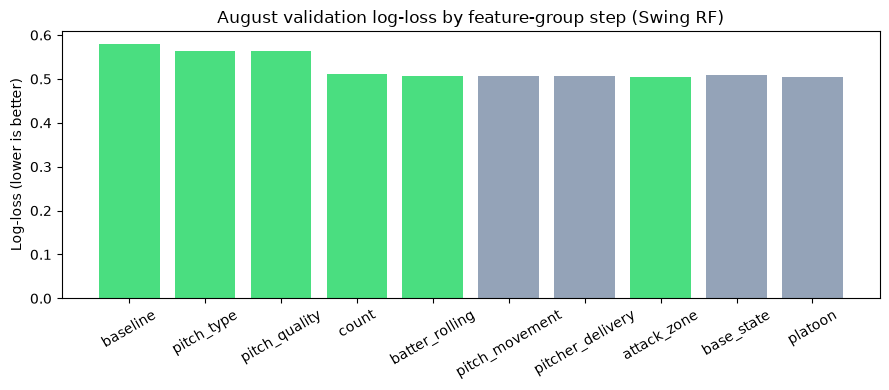

In [4]:
steps_df = pd.DataFrame(report.steps)
colors = ["#4ade80" if kept else "#94a3b8" for kept in steps_df["kept"]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(steps_df["step"], steps_df["val_log_loss"], color=colors)
ax.set_title("August validation log-loss by feature-group step (Swing RF)")
ax.set_ylabel("Log-loss (lower is better)")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()


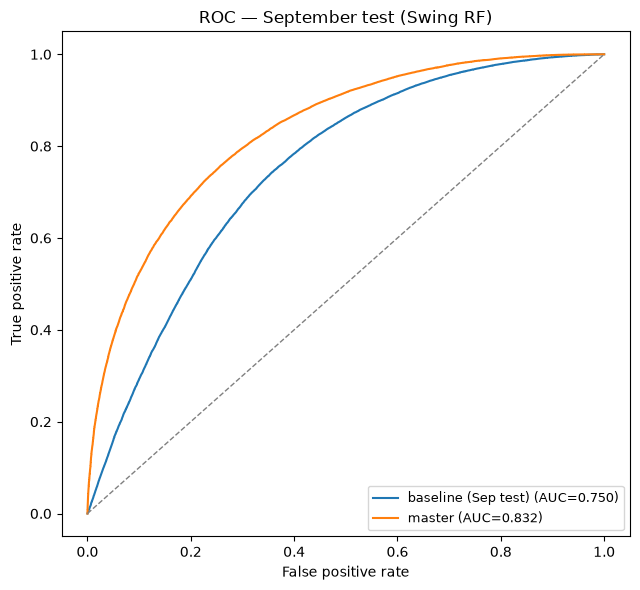

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for result in [baseline_master, master]:
    fpr, tpr = roc_curve_data(result)
    ax.plot(fpr, tpr, label=f"{result.name} (AUC={result.test_roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
ax.set_title("ROC — September test (Swing RF)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()


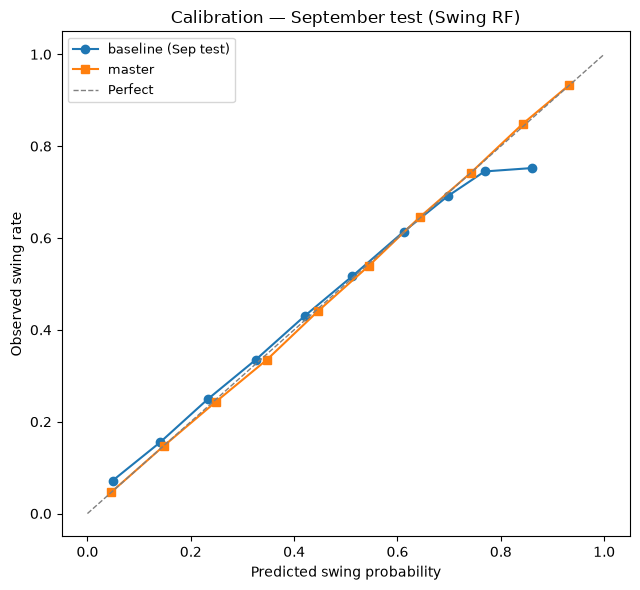

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for result, style in [(baseline_master, "o-"), (master, "s-")]:
    cal = calibration_bins(result.y_test, result.y_prob_test)
    ax.plot(cal["pred_mean"], cal["obs_rate"], style, label=result.name)
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Perfect")
ax.set_title("Calibration — September test (Swing RF)")
ax.set_xlabel("Predicted swing probability")
ax.set_ylabel("Observed swing rate")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()


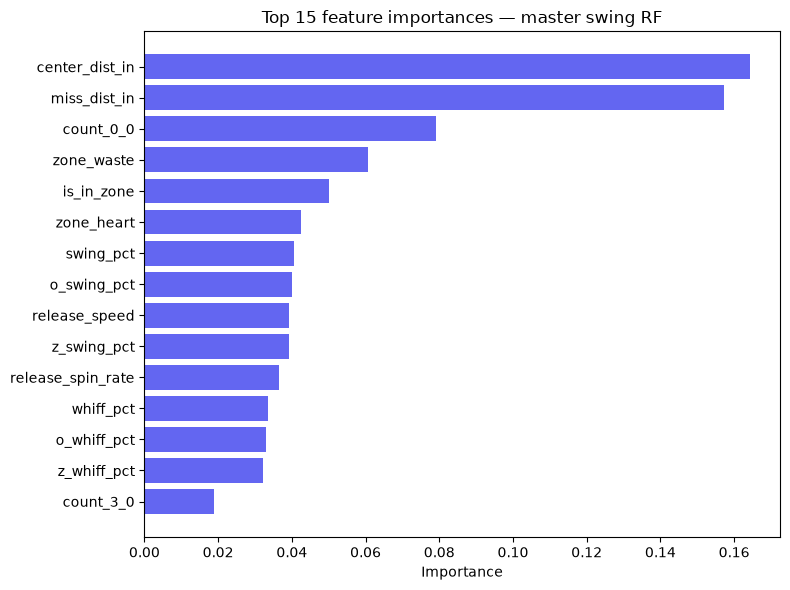

,feature,importance
0,center_dist_in,0.164231
1,miss_dist_in,0.157372
2,count_0_0,0.079027
3,zone_waste,0.060795
4,is_in_zone,0.050166
5,zone_heart,0.042594
6,swing_pct,0.040563
7,o_swing_pct,0.039954
8,release_speed,0.039256
9,z_swing_pct,0.039165


In [7]:
top15 = feature_importance_from_model(master.model, SELECTED_FEATURES).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15["feature"][::-1], top15["importance"][::-1], color="#6366f1")
ax.set_title("Top 15 feature importances — master swing RF")
ax.set_xlabel("Importance")
fig.tight_layout()
plt.show()

display(top15)


## 6. Save production artifact

In [8]:
import joblib

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
ARTIFACT_PATH = MODELS_DIR / "swing_rf_master.joblib"

artifact = {
    "model": master.model,
    "features": SELECTED_FEATURES,
    "target": TARGET,
    "train_end": str(TRAIN_END.date()),
    "val_end": str(VAL_END.date()),
    "test_log_loss": master.test_log_loss,
    "test_roc_auc": master.test_roc_auc,
    "test_brier": master.test_brier,
}

joblib.dump(artifact, ARTIFACT_PATH)
print(f"Saved master swing RF -> {ARTIFACT_PATH}")
print(f"Features: {len(SELECTED_FEATURES)}")


Saved master swing RF -> C:\Users\tabshire\Desktop\Portfolio\models\swing_rf_master.joblib
Features: 37


## 7. Summary

Re-run after updating `03_feature_engineering.ipynb`. Compare September test metrics to **`04_modeling_swing_logr.ipynb`**. Next: **`06_modeling_whiff_logr.ipynb`** / **`07_modeling_whiff_rf.ipynb`**.